Preuzimam mapu za: Novi Sad, Serbia. Ovo može potrajati minut-dva...
Mapa uspešno preuzeta!
Broj čvorova (raskrsnica): 2786
Broj grana (ulica): 6644


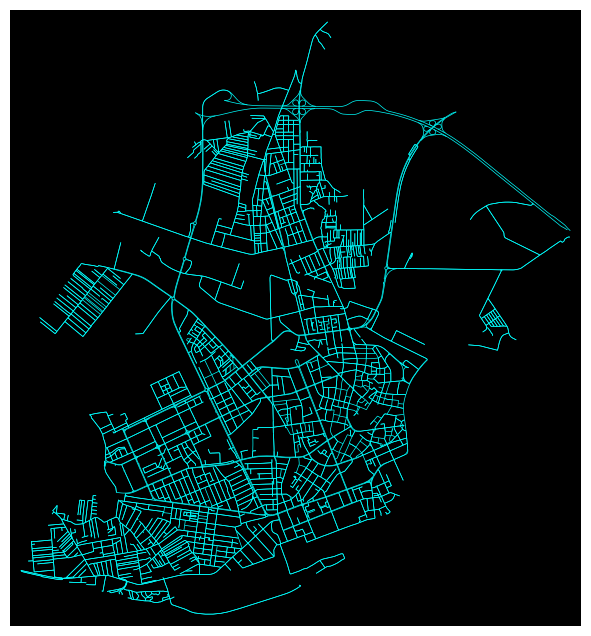

In [1]:
import osmnx as ox
import networkx as nx
import matplotlib.pyplot as plt

# Definišemo mesto koje preuzimamo
place_name = "Novi Sad, Serbia"

print(f"Preuzimam mapu za: {place_name}. Ovo može potrajati minut-dva...")

# Preuzimamo usmereni graf putne mreže (samo putevi za automobile)
G = ox.graph_from_place(place_name, network_type='drive')

# Ispisujemo osnovne informacije o grafu
num_nodes = len(G.nodes)
num_edges = len(G.edges)
print("Mapa uspešno preuzeta!")
print(f"Broj čvorova (raskrsnica): {num_nodes}")
print(f"Broj grana (ulica): {num_edges}")

# Iscrtavamo preuzeti graf
fig, ax = ox.plot_graph(G, node_size=0, edge_color="cyan", edge_linewidth=0.5, bgcolor="black")

ID pocetnog cvora (Hitna pomoc): 1319623584
ID ciljnog cvora (Mesto nesrece): 1533391269
Iscrtavam lokacije na mapi...


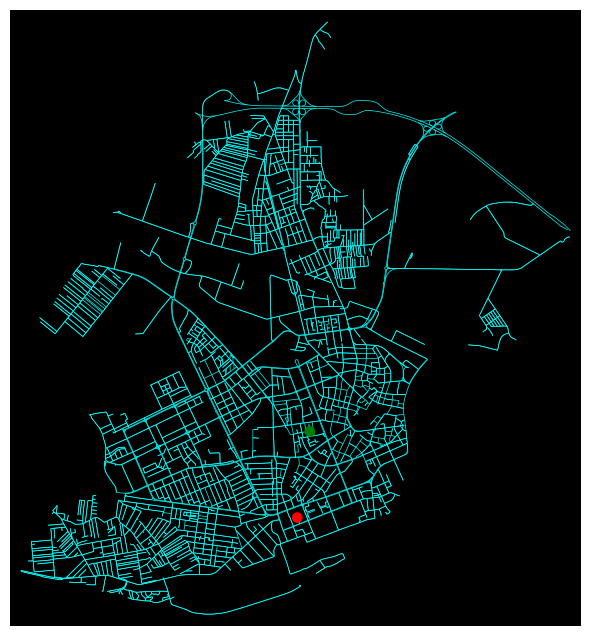

In [ ]:
# Tacne koordinate Klinickog centra Vojvodine (Pocetak - Hitna pomoc)
start_lat, start_lon = 45.2508, 19.8236

# Koordinate mesta nesrece (Npr. lokacija negde na Limanu/Grbavici)
goal_lat, goal_lon = 45.2400, 19.8300

# TRAZENJE NAJBLIZIH CVOROVA U GRAFU
# Napomene: osmnx funkcija prvo trazi X (longitude), pa onda Y (latitude)
start_node = ox.nearest_nodes(G, start_lon, start_lat)
goal_node = ox.nearest_nodes(G, goal_lon, goal_lat)

print(f"ID pocetnog cvora (Hitna pomoc): {start_node}")
print(f"ID ciljnog cvora (Mesto nesrece): {goal_node}")

# VIZUELIZACIJA TACAKA NA MAPI
# Bojimo startni cvor u zeleno, ciljni u crveno, ostale ostavljamo nevidljive
node_colors = ['green' if node == start_node else 'red' if node == goal_node else 'none' for node in G.nodes()]
node_sizes = [60 if node in [start_node, goal_node] else 0 for node in G.nodes()]

print("Iscrtavam korigovane lokacije na mapi...")
fig, ax = ox.plot_graph(
    G, 
    node_color=node_colors, 
    node_size=node_sizes, 
    edge_color="cyan", 
    edge_linewidth=0.5, 
    bgcolor="black"
)